In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

2026-03-30 18:45:23.514591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774896323.723417      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774896323.780834      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774896324.298346      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774896324.298392      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774896324.298396      55 computation_placer.cc:177] computation placer alr

In [3]:
import os
import shutil

original_dir = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

base_dir = "/kaggle/working/tomato_only"

if not os.path.exists(base_dir):
    os.makedirs(base_dir)


for class_name in os.listdir(original_dir):
    if "Tomato" in class_name:  
        src = os.path.join(original_dir, class_name)
        dst = os.path.join(base_dir, class_name)
        shutil.copytree(src, dst)


data_dir = base_dir


classes = os.listdir(data_dir)
print("Total Classes:", len(classes))
print(classes)

Total Classes: 10
['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy', 'Tomato__Target_Spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Septoria_leaf_spot', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot']


In [14]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False 
)

Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.7528202115158636), 1: np.float64(1.601625), 2: np.float64(0.8385471204188482), 3: np.float64(1.681496062992126), 4: np.float64(0.9042342978122795), 5: np.float64(0.9554809843400447), 6: np.float64(1.139946619217082), 7: np.float64(0.4991429684456564), 8: np.float64(4.285284280936454), 9: np.float64(1.006520031421838)}


In [7]:
from tensorflow.keras import Input

model = models.Sequential()

# Input layer
model.add(Input(shape=(224,224,3)))

# Block 1
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 2
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 3
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 4
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# FC
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,238,218 (50.50 MB)

 Trainable params: 13,237,258 (50.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop],
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1774898755.256430     163 service.cc:152] XLA service 0x784a74015400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774898755.256490     163 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774898755.256496     163 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774898755.959425     163 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/401 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.1641 - loss: 11.7566  

I0000 00:00:1774898764.146298     163 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


401/401 ━━━━━━━━━━━━━━━━━━━━ 193s 452ms/step - accuracy: 0.2870 - loss: 4.8751 - val_accuracy: 0.2111 - val_loss: 9.7530
Epoch 2/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 173s 432ms/step - accuracy: 0.2588 - loss: 2.2395 - val_accuracy: 0.3674 - val_loss: 3.1281
Epoch 3/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 173s 431ms/step - accuracy: 0.3211 - loss: 2.0648 - val_accuracy: 0.2871 - val_loss: 1.9362
Epoch 4/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 171s 426ms/step - accuracy: 0.3098 - loss: 2.0171 - val_accuracy: 0.4006 - val_loss: 1.6952
Epoch 5/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 172s 428ms/step - accuracy: 0.2883 - loss: 2.0278 - val_accuracy: 0.3030 - val_loss: 1.9048
Epoch 6/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 170s 425ms/step - accuracy: 0.3238 - loss: 1.9648 - val_accuracy: 0.1104 - val_loss: 2.5364
Epoch 7/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 173s 431ms/step - accuracy: 0.3142 - loss: 1.9469 - val_accuracy: 0.4615 - val_loss: 1.6079
Epoch 8/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 174s 433ms/step - accuracy: 0.3272 - loss: 1.92

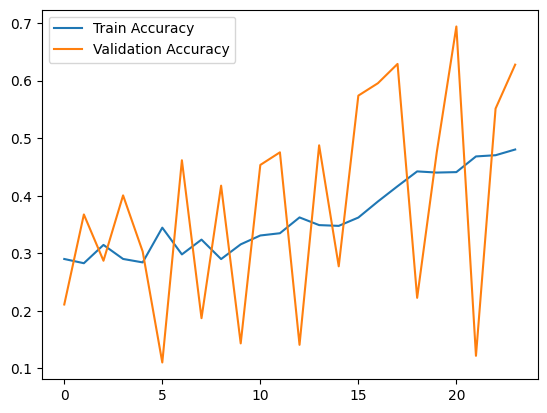

In [18]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [16]:
val_data.reset()
pred = model.predict(val_data)

y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

print(classification_report(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 334ms/step
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       425
           1       0.46      0.74      0.57       200
           2       0.95      0.56      0.70       381
           3       0.56      0.76      0.64       190
           4       0.73      0.53      0.61       354
           5       0.72      0.83      0.77       335
           6       0.65      0.32      0.43       280
           7       0.97      0.93      0.95       641
           8       0.14      0.91      0.24        74
           9       0.99      0.36      0.53       318

    accuracy                           0.69      3198
   macro avg       0.71      0.68      0.64      3198
weighted avg       0.81      0.69      0.71      3198



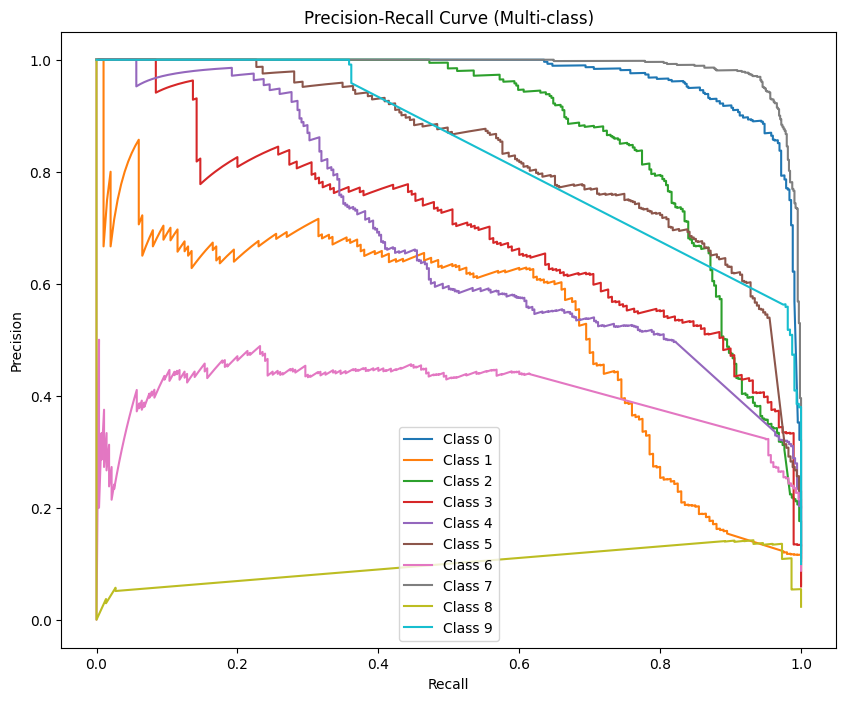

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# True labels one-hot
y_true_bin = label_binarize(y_true, classes=range(10))

# Plot PR curve for each class
plt.figure(figsize=(10,8))

for i in range(10):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multi-class)')
plt.legend(loc='best')
plt.show()

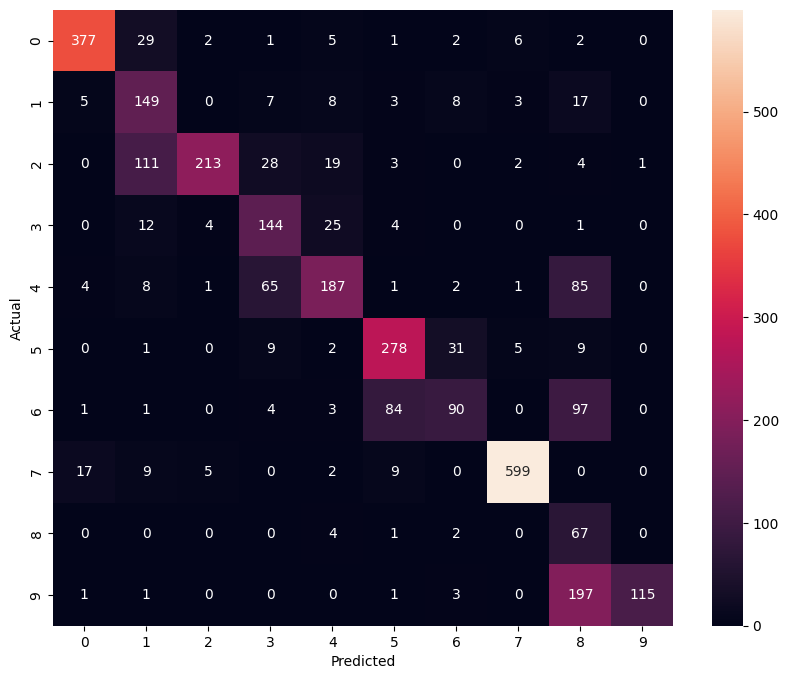

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
